# 04 · Resultados, comparación con los modelos base y ablación

**Preguntas que responde este notebook**

1. ¿Adapformer supera a la persistencia y al LSTM? ¿En qué métrica y en qué horizonte?
2. ¿Cuánto varía el resultado entre semillas? ¿Sirve ensamblar?
3. **Ablación de componentes del paper:** ¿qué pasa si quitamos ACE, la pérdida auxiliar o la selección top-k?
4. **Ablación de las mejoras propuestas:** ¿la pérdida híbrida, el token de cuenca o EMA ayudan?
5. ¿Qué canales elige realmente el ACF?

> Todas las decisiones se toman con **validación**. El test aparece sólo en el notebook 05.
> Con 3 semillas, una diferencia sólo la consideramos real si supera ~2σ **y** se confirma por cuenca (Wilcoxon).

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.5f}")
from resultados import *
from datos import DATASET
SEM = (42, 43, 44)
FINAL = [f"final_cd_s{s}" for s in SEM]        # Adapformer FINAL: k = 12 (CD), 3 semillas — elegido por val MSE
K4 = [f"p1_log_s{s}" for s in SEM]              # Adapformer con top-k adaptativo (k = 4, método completo del paper)
LSTM = [f"lstm_s{s}" for s in SEM]              # modelo base
E1 = pd.read_csv(ROOT / "referencias_estudio1" / "resultados_val.csv").set_index("run")

## 1. Tabla principal (validación, 18 142 ventanas, mm/h)

In [2]:
def fila(nombre, p, extra=""):
    m = metricas_de(p, "validation")
    return {"modelo": nombre, "MSE": m["MSE"], "MAE": m["MAE"], "NSE mediana": m["NSE_median"], "NSE p25": m["NSE_p25"],
            "KGE mediana": m["KGE_median"], "MSE h=1": m["MSE_h1"], "MSE h=48": m["MSE_h48"], "nota": extra}

def media_sd(runs):
    t = tabla(runs)
    return f"{t.MSE.mean():.5f} ± {t.MSE.std():.5f}"

P_PERS, P_AF, P_LSTM = persistencia("validation"), ensamble(FINAL), ensamble(LSTM)
filas = [fila("Persistencia", P_PERS, "sin entrenamiento"),
         {"modelo": "Versión inicial · Adapformer k=4 (1 semilla)", **{k: E1.loc["adapformer_full", c] for k, c in
          [("MSE", "MSE"), ("MAE", "MAE"), ("NSE mediana", "NSE_median"), ("NSE p25", "NSE_p25"), ("KGE mediana", "KGE_median"), ("MSE h=1", "MSE_h1"), ("MSE h=48", "MSE_h48")]}, "nota": "primera implementación"},
         {"modelo": "Versión inicial · LSTM (1 semilla)", **{k: E1.loc["lstm_tuned", c] for k, c in
          [("MSE", "MSE"), ("MAE", "MAE"), ("NSE mediana", "NSE_median"), ("NSE p25", "NSE_p25"), ("KGE mediana", "KGE_median"), ("MSE h=1", "MSE_h1"), ("MSE h=48", "MSE_h48")]}, "nota": ""},
         fila("Adapformer k=4 · semilla 42", pred(K4[0]), f"3 semillas: {media_sd(K4)}"),
         fila("Adapformer k=4 · ensamble 3 semillas", ensamble(K4), "top-k adaptativo (paper)"),
         fila("Adapformer k=12 · semilla 42", pred(FINAL[0]), f"3 semillas: {media_sd(FINAL)}"),
         fila("Adapformer k=12 · ensamble 3 semillas", P_AF, "MODELO FINAL"),
         fila("LSTM · semilla 42", pred(LSTM[0]), f"3 semillas: {media_sd(LSTM)}"),
         fila("LSTM · ensamble 3 semillas", P_LSTM, "modelo base"),
         fila("Adapformer ×3 + LSTM ×3", (P_AF + P_LSTM) / 2, "ensamble mixto")]
T = pd.DataFrame(filas).set_index("modelo")
T

,MSE,MAE,NSE mediana,NSE p25,KGE mediana,MSE h=1,MSE h=48,nota
modelo,,,,,,,,
Persistencia,0.01901,0.02446,0.52509,0.15919,0.65255,0.00118,0.02637,sin entrenamiento
Versión inicial · Adapformer k=4 (1 semilla),0.01222,0.01931,0.66258,0.34045,0.69805,0.00115,0.01488,primera implementación
Versión inicial · LSTM (1 semilla),0.01128,0.01886,0.66461,0.34265,0.70956,0.00106,0.01453,
Adapformer k=4 · semilla 42,0.01195,0.01944,0.64713,0.32729,0.67229,0.00117,0.01497,3 semillas: 0.01205 ± 0.00012
Adapformer k=4 · ensamble 3 semillas,0.01192,0.01908,0.64137,0.34276,0.67281,0.00114,0.01512,top-k adaptativo (paper)
Adapformer k=12 · semilla 42,0.01120,0.01900,0.64671,0.32960,0.71463,0.00119,0.01473,3 semillas: 0.01132 ± 0.00019
Adapformer k=12 · ensamble 3 semillas,0.01117,0.01863,0.66274,0.35459,0.72213,0.00126,0.01465,MODELO FINAL
LSTM · semilla 42,0.01147,0.01919,0.64745,0.34694,0.70049,0.00107,0.01468,3 semillas: 0.01119 ± 0.00024
LSTM · ensamble 3 semillas,0.01101,0.01866,0.66125,0.36271,0.70860,0.00105,0.01442,modelo base


**Cómo leer la tabla**

* Todos los modelos entrenados reducen el MSE de la persistencia en más de un tercio y suben la NSE mediana de 0.53 a ~0.65.
* **Ensamblar semillas** baja el MSE de forma consistente: promediar modelos con errores parcialmente independientes
  reduce la varianza (la validación oscila mucho de época a época, notebook 03).
* **k = 12 frente a k = 4:** usar todos los canales en el ACF baja el MSE ~6 % en las tres semillas y no empeora la NSE
  (sección 5). Por eso el modelo final es Adapformer con k = 12, elegido **sólo con validación**.
* Compara Adapformer con el LSTM **con la misma pérdida, anclaje y scheduler**: la diferencia es sólo arquitectónica.
  Quedan prácticamente empatados; el ensamble de ambos es el mejor número, pero ya no es "el método del paper".

## 2. Error por horizonte

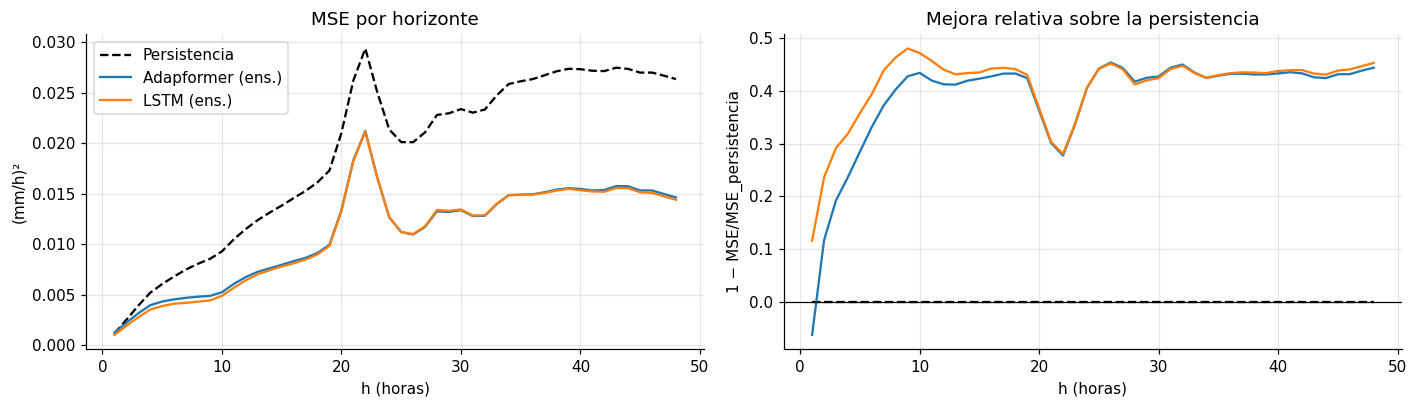

In [3]:
y, b, _ = verdad("validation")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for nombre, p, st in [("Persistencia", P_PERS, "k--"), ("Adapformer (ens.)", P_AF, "C0-"), ("LSTM (ens.)", P_LSTM, "C1-")]:
    ax[0].plot(range(1, 49), ((p - y) ** 2).mean(0), st, label=nombre)
    ax[1].plot(range(1, 49), 1 - ((p - y) ** 2).mean(0) / ((P_PERS - y) ** 2).mean(0), st, label=nombre)
ax[0].set(title="MSE por horizonte", xlabel="h (horas)", ylabel="(mm/h)²"); ax[0].legend()
ax[1].set(title="Mejora relativa sobre la persistencia", xlabel="h (horas)", ylabel="1 − MSE/MSE_persistencia"); ax[1].axhline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

A 1 h la persistencia es casi imbatible (el caudal casi no cambia en una hora); gracias al **anclaje** los modelos la
*casi* igualan (Adapformer queda ~6 % peor a 1 h; el LSTM, que recorre la serie hora a hora, algo mejor). A partir de
~3 h los modelos aprendidos ganan, con una mejora de ~40–45 % desde las 10 h. El pico de error cerca de h ≈ 22 viene de
unas pocas crecidas grandes de validación que empiezan en ese momento.

## 3. Por régimen: crecidas vs régimen normal

In [4]:
reg = {}
for nombre, p in [("Persistencia", P_PERS), ("Adapformer (ens.)", P_AF), ("LSTM (ens.)", P_LSTM)]:
    m = metricas_de(p, "validation")
    reg[nombre] = {"MSE crecida": m["MSE_flood"], "MSE normal": m["MSE_normal"], "sesgo crecida": m["bias_flood"],
                   "error rel. del pico (mediana)": m["peak_rel_err_flood"],
                   "% del MSE por crecidas": 100 * 0.1 * m["MSE_flood"] / m["MSE"]}
pd.DataFrame(reg).T

,MSE crecida,MSE normal,sesgo crecida,error rel. del pico (mediana),% del MSE por crecidas
Persistencia,0.18757,0.00027,-0.00327,-0.21185,98.69235
Adapformer (ens.),0.10960,0.00022,-0.06822,-0.17625,98.15199
LSTM (ens.),0.10785,0.00024,-0.06322,-0.16102,97.98887


El 10 % de ventanas con crecida aporta ~98 % del MSE y **todos** los modelos subestiman los picos (sesgo negativo).
Por eso el MSE global y la NSE mediana pueden ordenar distinto a los modelos.

## 4. Por cuenca: distribución de la NSE y prueba de Wilcoxon

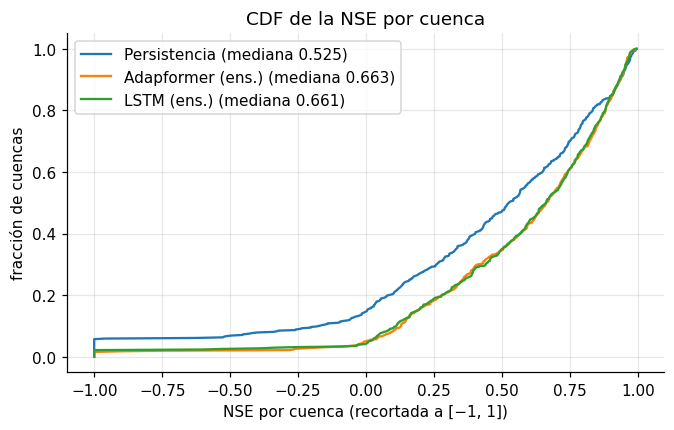

% de cuencas con NSE < 0: {'Persistencia': np.float64(14.8), 'Adapformer (ens.)': np.float64(5.1), 'LSTM (ens.)': np.float64(4.3)}


,gana_A_%,dif_mediana,p_valor
Adapformer vs persistencia,67.71654,0.05405,0.00000
Adapformer vs LSTM,45.27559,-0.00403,0.03294


In [5]:
nse = {n: nse_por_cuenca(p) for n, p in [("Persistencia", P_PERS), ("Adapformer (ens.)", P_AF), ("LSTM (ens.)", P_LSTM)]}
plt.figure(figsize=(7, 4))
for n, s in nse.items():
    v = np.sort(s.dropna().clip(-1, 1)); plt.plot(v, np.linspace(0, 1, len(v)), label=f"{n} (mediana {s.median():.3f})")
plt.xlabel("NSE por cuenca (recortada a [−1, 1])"); plt.ylabel("fracción de cuencas"); plt.legend(); plt.title("CDF de la NSE por cuenca"); plt.show()
print("% de cuencas con NSE < 0:", {n: round(100 * (s < 0).mean(), 1) for n, s in nse.items()})
display(pd.DataFrame({"Adapformer vs persistencia": wilcoxon_cuencas(P_AF, P_PERS),
                      "Adapformer vs LSTM": wilcoxon_cuencas(P_AF, P_LSTM)}).T)

`gana_A_%` = porcentaje de cuencas donde el primer modelo tiene mayor NSE; `p_valor` < 0.05 → la diferencia por
cuenca es sistemática y no ruido.

## 5. Ablación (3 semillas por variante)

Hacemos dos bloques de ablación. Cada variante cambia **una** cosa.

**Bloque A: ¿cuántos canales debe mirar el ACF?** (referencia: modelo FINAL, k = 12)

| Variante | Qué cambia | Pregunta |
|---|---|---|
| `abl_ci` | k = 1 (sólo el caudal) | ¿sirve mirar otros canales? (channel-independent) |
| `p1_log` | k = 4 elegidos por el SimBlock (top-k, **el método del paper**) | ¿sirve **seleccionar** adaptativamente? |
| `cd_noace` | k = 12 sin ACE | ¿aporta ACE en el modelo final? |

**Bloque B: componentes del método completo** (referencia: k = 4 adaptativo, donde el SimBlock sí decide)

| Variante | Qué cambia | Pregunta |
|---|---|---|
| `abl_noace` | sin ACE | ¿aporta el realce de bajo rango? |
| `abl_noaux` | sin pérdida auxiliar (Ec. 6) | ¿aporta supervisar el SimBlock con el futuro? |

,MSE media,σ,Δ MSE,Δ/σ,NSE med (media),Δ NSE,gana variante % (NSE cuenca),p Wilcoxon
FINAL k=12 (CD),0.01132,0.00019,0.00000,0.00000,0.65208,0.00000,NaN,NaN
k=1 (CI),0.01208,0.00013,0.00076,4.58077,0.63687,-0.01522,40.74803,0.00001
k=4 top-k (paper),0.01205,0.00012,0.00073,4.51856,0.64464,-0.00744,40.74803,0.00006
k=12 sin ACE,0.01165,0.00015,0.00033,1.89948,0.60137,-0.05071,36.61417,0.00000


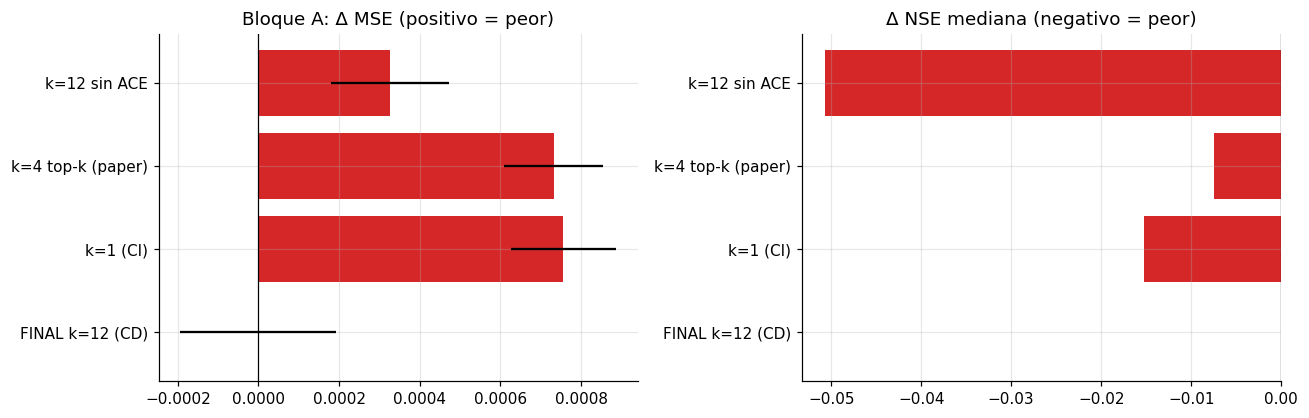

,MSE media,σ,Δ MSE,Δ/σ,NSE med (media),Δ NSE,gana variante % (NSE cuenca),p Wilcoxon
k=4 (método completo),0.01205,0.00012,0.00000,0.00000,0.64464,0.00000,NaN,NaN
sin ACE,0.01206,0.00013,0.00001,0.08021,0.63266,-0.01198,52.16535,0.83346
sin pérdida aux.,0.01229,0.00008,0.00024,2.31524,0.63437,-0.01028,49.21260,0.20268


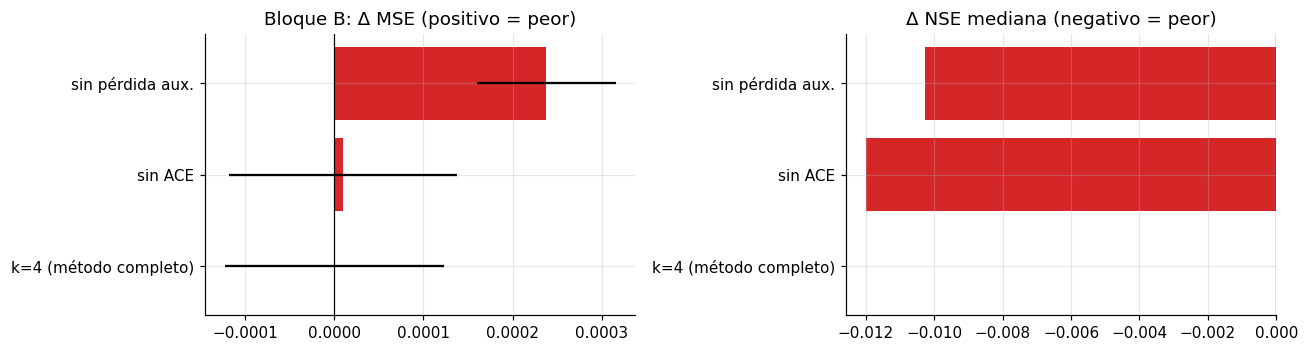

In [6]:
def ablacion(variantes, ref, ref_nombre):
    tr = tabla(ref); filas = {}
    p_ref = ensamble(ref)
    filas[ref_nombre] = {"MSE media": tr.MSE.mean(), "σ": tr.MSE.std(), "Δ MSE": 0, "Δ/σ": 0,
                         "NSE med (media)": tr.NSE_median.mean(), "Δ NSE": 0, "gana variante % (NSE cuenca)": np.nan, "p Wilcoxon": np.nan}
    for nombre, pref in variantes.items():
        runs = [f"{pref}_s{s}" for s in SEM if (OUT / f"{pref}_s{s}" / "resumen.json").exists()]
        if not runs: continue
        t = tabla(runs); sd = np.sqrt((tr.MSE.var() + t.MSE.var()) / 2) if len(runs) > 1 else np.nan
        w = wilcoxon_cuencas(ensamble(runs), p_ref)
        filas[nombre] = {"MSE media": t.MSE.mean(), "σ": t.MSE.std(), "Δ MSE": t.MSE.mean() - tr.MSE.mean(),
                         "Δ/σ": (t.MSE.mean() - tr.MSE.mean()) / sd, "NSE med (media)": t.NSE_median.mean(),
                         "Δ NSE": t.NSE_median.mean() - tr.NSE_median.mean(),
                         "gana variante % (NSE cuenca)": w["gana_A_%"], "p Wilcoxon": w["p_valor"]}
    return pd.DataFrame(filas).T

def grafico(A, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 0.6 * len(A) + 1.5))
    ax[0].barh(A.index, A["Δ MSE"], xerr=A["σ"], color=["gray"] + ["C3" if v > 0 else "C2" for v in A["Δ MSE"][1:]])
    ax[0].axvline(0, color="k", lw=.8); ax[0].set_title(f"{titulo}: Δ MSE (positivo = peor)")
    ax[1].barh(A.index, A["Δ NSE"], color=["gray"] + ["C2" if v > 0 else "C3" for v in A["Δ NSE"][1:]])
    ax[1].axvline(0, color="k", lw=.8); ax[1].set_title("Δ NSE mediana (negativo = peor)")
    plt.tight_layout(); plt.show()

A1 = ablacion({"k=1 (CI)": "abl_ci", "k=4 top-k (paper)": "p1_log", "k=12 sin ACE": "cd_noace"}, FINAL, "FINAL k=12 (CD)")
display(A1); grafico(A1, "Bloque A")
A2 = ablacion({"sin ACE": "abl_noace", "sin pérdida aux.": "abl_noaux"}, K4, "k=4 (método completo)")
display(A2); grafico(A2, "Bloque B")

**Cómo interpretar:** `Δ/σ` mide el cambio en unidades de la variabilidad entre semillas (|Δ/σ| < 2 → no
distinguible del ruido con 3 semillas). La prueba por cuenca (`gana variante %`, `p Wilcoxon`) usa las 508 cuencas y es
mucho más sensible. `gana variante %` < 50 con p pequeño significa que la variante es **peor** que la referencia.

**Conclusiones**

1. **Mirar todos los canales (k = 12) es lo mejor en este dataset.** k = 1 y k = 4 tienen ~6 % más MSE y pierden por
   cuenca (p < 0.001). La *selección adaptativa*, que es la idea central del paper, no aporta aquí: con sólo 12 canales,
   todos mezclados por la atención del encoder, no hay "ruido" que filtrar. El paper muestra sus mayores ganancias con
   cientos de variables (PEMS: 358–883). La versión inicial ya mostraba lo mismo en MSE (k = 12: −3.7σ), pero se había elegido k = 4 por
   la NSE mediana; con 3 semillas vemos que k = 12 **también** tiene mejor NSE y KGE.
2. **ACE es el componente con efecto más claro en el modelo final:** sin ACE el MSE sube ~3 % y la NSE mediana cae
   ~0.05; pierde en ~63 % de las cuencas (p ≈ 10⁻¹⁴). Coincide con la ablación de la versión inicial.
3. **Pérdida auxiliar (Ec. 6):** en k = 4 quitarla sube algo el MSE (~2σ) sin diferencia clara por cuenca. En k = 12
   el SimBlock ya no decide nada en la predicción, así que su efecto desaparece por construcción.
4. En k = 4 quitar ACE no cambia el resultado de forma significativa; en k = 12 sí. ACE realza todos los tokens, pero
   sólo se aprovecha del todo cuando el predictor los usa todos.

## 6. Ablación de las mejoras propuestas

Se probaron sobre la configuración inicial (k = 4, pérdida log), antes de descubrir lo de k = 12.

| Variante | Hipótesis | Resultado esperado |
|---|---|---|
| `p1_hib1`, `p1_hib3` | Pérdida híbrida log + λ·mm/h (λ = 1, 3) | Bajar el MSE alineando la pérdida con la métrica |
| `p1_logbas` | Token de cuenca (embedding de `basin_id`) | Personalizar la respuesta por cuenca |
| `p1_logema` | Promedio móvil (EMA) de los pesos | Reducir la oscilación entre épocas |

In [7]:
A3 = ablacion({"híbrida λ=1": "p1_hib1", "híbrida λ=3": "p1_hib3", "token de cuenca": "p1_logbas", "EMA 0.999": "p1_logema"},
              K4, "k=4, pérdida log (referencia)")
display(A3)
af = {r: resumen(r)["val"] for r in ["af_log", "af_hib", "af_mmh", "af_hib_bas"] if (OUT / r / "resumen.json").exists()}
print("Fase 1 exploratoria (1 semilla; λ=20 resultó demasiado grande):")
display(pd.DataFrame(af).T[["MSE", "NSE_median", "KGE_median"]])

,MSE media,σ,Δ MSE,Δ/σ,NSE med (media),Δ NSE,gana variante % (NSE cuenca),p Wilcoxon
"k=4, pérdida log (referencia)",0.01205,0.00012,0.00000,0.00000,0.64464,0.00000,NaN,NaN
híbrida λ=1,0.01242,0.00023,0.00037,2.00114,0.63421,-0.01044,47.83465,0.05480
híbrida λ=3,0.01219,0.00006,0.00014,1.40714,0.63149,-0.01315,46.45669,0.03098
token de cuenca,0.01233,0.00012,0.00028,2.27394,0.62566,-0.01898,44.48819,0.00251
EMA 0.999,0.01214,0.00014,0.00009,0.69420,0.64251,-0.00213,53.34646,0.34839


Fase 1 exploratoria (1 semilla; λ=20 resultó demasiado grande):


,MSE,NSE_median,KGE_median
af_log,0.01195,0.64713,0.67229
af_hib,0.01219,0.61225,0.66299
af_mmh,0.01244,0.58275,0.66062
af_hib_bas,0.01240,0.62591,0.67927


**Lectura honesta:** ninguna de las tres ideas mejoró de forma significativa a la configuración final.

* **Pérdida híbrida / mm/h:** alinear la pérdida con la métrica *parecía* obvio, pero la respuesta de la cuenca a la
  lluvia es **muy incierta**: incluso con 10–30 mm en 24 h solo ~30 % de las ventanas termina en crecida (notebook 05).
  Darles más peso a las crecidas sin poder distinguir cuáles ocurrirán no aporta información, sólo varianza: el modelo
  aprende a "subir un poco todo" en ventanas lluviosas que no tendrán crecida.
* **Token de cuenca:** 14 días de historia ya identifican bien el comportamiento de la cuenca (RevIN + anclaje); el
  embedding agrega 130 000 parámetros que tienden a sobreajustar.
* **EMA:** la oscilación de la validación no viene de los pesos sino de **qué crecidas** caen bien o mal en cada época.

### 6b. ¿Se puede hacer que Adapformer supere al LSTM? (fase 4, sobre el modelo final k = 12)

Hipótesis: el cuello de botella es el **embedding lineal** (`Linear(336→256)` comprime las 336 h de cada canal), mientras
que el LSTM recorre la serie hora a hora. Probamos dos cambios dentro del método:

| Variante | Qué cambia |
|---|---|
| `cd_embmlp` | Embedding con rama no lineal residual: `e = Linear(x); e = e + Linear(GELU(e))` |
| `cd_r64` | Rango de ACE más alto (r = 64, d = 128); el apéndice B del paper muestra que r es sensible |

In [8]:
A4 = ablacion({"embedding MLP": "cd_embmlp", "ACE r=64": "cd_r64"}, FINAL, "FINAL k=12 (r=32, embedding lineal)")
display(A4)
for nombre, runs in {"FINAL ×3": FINAL, "FINAL + r64 (×6)": FINAL + [f"cd_r64_s{s}" for s in SEM], "LSTM ×3": LSTM}.items():
    print(f"{nombre:18s} val MSE del ensamble: {metricas_de(ensamble(runs))['MSE']:.5f}")

,MSE media,σ,Δ MSE,Δ/σ,NSE med (media),Δ NSE,gana variante % (NSE cuenca),p Wilcoxon
"FINAL k=12 (r=32, embedding lineal)",0.01132,0.00019,0.00000,0.00000,0.65208,0.00000,NaN,NaN
embedding MLP,0.01195,0.00012,0.00063,3.95488,0.61704,-0.03504,38.97638,0.00000
ACE r=64,0.01167,0.00025,0.00035,1.57417,0.64775,-0.00433,44.88189,0.00623


FINAL ×3           val MSE del ensamble: 0.01117


FINAL + r64 (×6)   val MSE del ensamble: 0.01130
LSTM ×3            val MSE del ensamble: 0.01101


**Resultado:** ninguno de los dos supera al modelo final. El embedding MLP se sobreajusta enseguida (su mejor época
es la 1 en dos de las tres semillas) y r = 64 queda algo peor que r = 32. Ampliar el ensamble a 6 modelos tampoco
mejora la validación. En validación el LSTM sigue ligeramente arriba (gana en ~55 % de las cuencas, p ≈ 0.03); en test
el ensamble de Adapformer es ligeramente mejor (0.01086 frente a 0.01091). Es un **empate práctico**.

Lo que **sí** funcionó en todos los experimentos: usar k = 12 (sección 5) y ensamblar semillas (sección 1). Un resultado
negativo bien medido también es un resultado.

## 7. ¿Qué canales elige el ACF? (modelo k = 4, donde el SimBlock sí decide)

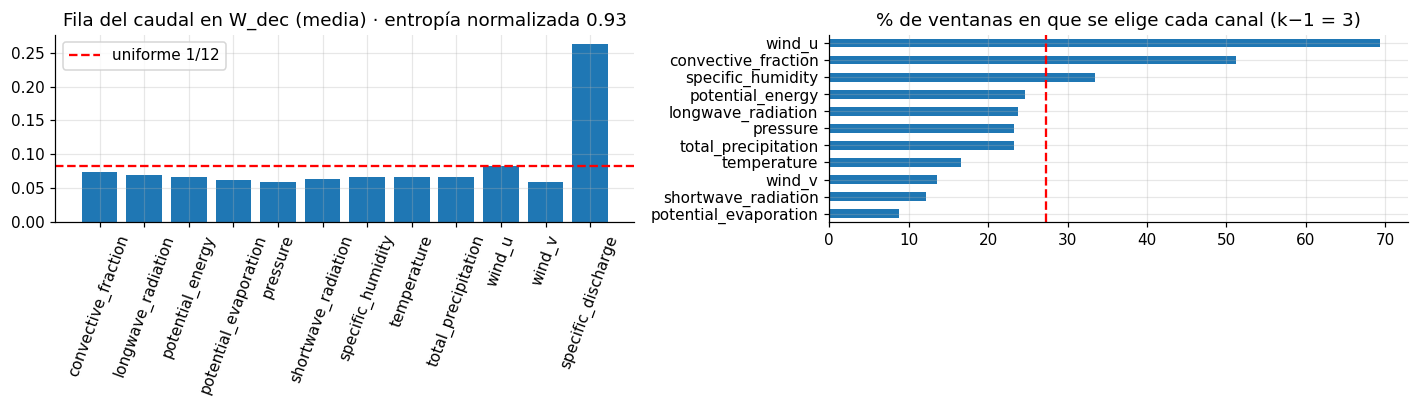

In [9]:
import torch
from modelos import construir
from datos import cargar, mapa_cuencas
dev = "cuda" if torch.cuda.is_available() else "cpu"
st = torch.load(OUT / K4[0] / "best.pt", map_location=dev, weights_only=False)
model = construir(st["cfg"]["model"]).to(dev); model.load_state_dict(st["model"]); model.eval()
va = cargar("validation", dev)
W, S = [], []
with torch.no_grad():
    for s in range(0, va["n"], 4096):
        o = model(va["X"][s:s + 4096].float())
        W.append(o["W_dec"][:, 11].cpu()); S.append(o["sel"].cpu())
W, S = torch.cat(W).numpy(), torch.cat(S).numpy()
NOMBRES = [c["name"] for c in json.loads((DATASET / "metadata.json").read_text())["channels"]]
H = -(W * np.log(W + 1e-12)).sum(1) / np.log(12)
freq = pd.Series(np.bincount(S[:, 1:].ravel(), minlength=12) / len(S) * 100, index=NOMBRES).drop("specific_discharge")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(NOMBRES, W.mean(0)); ax[0].axhline(1 / 12, color="r", ls="--", label="uniforme 1/12"); ax[0].legend()
ax[0].set_title(f"Fila del caudal en W_dec (media) · entropía normalizada {H.mean():.2f}"); ax[0].tick_params(axis="x", rotation=70)
freq.sort_values().plot.barh(ax=ax[1]); ax[1].axvline(300 / 11, color="r", ls="--"); ax[1].set_title("% de ventanas en que se elige cada canal (k−1 = 3)")
plt.tight_layout(); plt.show()

Una entropía normalizada cercana a 1 significa que la fila del caudal en `W_dec` es casi uniforme: el SimBlock
**apenas discrimina** entre canales meteorológicos para el caudal, y el top-k se decide por diferencias de centésimas.
Coherente con el EDA (|r| ≈ 0.1) y con la ablación: si la selección es casi aleatoria, conviene no seleccionar (k = 12).